# Compare Views With and Without Scatter Weights

This notebook loads a random TIC ID and generates views with and without scatter weights to compare the differences.


## Setup


In [146]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional

# Adjust paths as needed
# input_tce_csv_file = "/pdo/astronet-data/data/properties/tces-sector87.csv"
# tess_data_dir = "/pdo/astronet-data/data/fits/sector-87-p"

input_tce_csv_file = "/pdo/users/pablomer/mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-april2025-all.csv"
tess_data_dir = '/pdo/users/pablomer/mnt/tess/april2025_dataset_fits_files'

# Change to Astronet-Triage directory if needed
os.chdir('/pdo/users/pablomer/Astronet-Triage')
sys.path.insert(0, "/pdo/users/pablomer/Astronet-Triage")

from astronet.preprocess import preprocess


## Load Random TCE


In [147]:
# Load TCE table
tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)

# Pick a random astro ID
astro_id_to_inspect = np.random.choice(tce_table["Astro ID"].unique())
print(f"Randomly selected Astro ID: {astro_id_to_inspect}")

# Get TCE data
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(f"\nTIC ID: {tce['TIC ID']}")
print(f"Period: {tce.Per:.4f} days")
print(f"Epoch: {tce.Epoc:.4f}")
print(f"Duration: {tce.Dur:.4f} days")


Randomly selected Astro ID: 4338

TIC ID: 43429656
Period: 5.2132 days
Epoch: 1983.9662
Duration: 0.1827 days


## Helper Functions


In [148]:
def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    """Load light curve data for a given astro ID."""
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }

    matching_tces = tce_table[tce_table["Astro ID"] == astro_id]
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e

    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf

    # Use the File column from the TCE table if available, otherwise construct filename
    if "File" in tce and pd.notna(tce["File"]):
        filename = tce["File"]
    else:
        # Fallback: construct filename (adjust format as needed for your data)
        astro_id_str = str(int(astro_id))[:-2].zfill(16)
        filename = (
        f"{tess_data_dir}/astronet_hlsp_qlp_tess_ffi-s0087-{astro_id_str}_tess_v01_llc.fits"
        )

    # pad with enough zeros for astronet_hlsp_qlp_tess_ffi-s0087-0000000097156957_tess_v01_llc.fits

    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        filename,
        tce.MinT,
        tce.MaxT,
    )


## Process Light Curve


In [149]:
# Load light curve
time, flux = get_lightcurve(tce['Astro ID'])
print(f"Loaded {len(time)} data points")
print(f"Time range: {time.min():.2f} to {time.max():.2f}")
print(f"Flux range: {flux.min():.4f} to {flux.max():.4f}")

# Detrend and filter
detrended_time, detrended_flux, transit_mask = preprocess.detrend_and_filter(
    tce['TIC ID'], time, flux, tce.Per, tce.Epoc, tce.Dur, fixed_bkspace=None
)

# Ensure epoch is within detrended time range
epoch = tce.Epoc
while epoch < detrended_time[0]:
    epoch += tce.Per


Loaded 6104 data points
Time range: 1983.70 to 2768.88
Flux range: 0.9937 to 1.0046


## Calculate Scatter Weights


Scatter weights calculated: 6104 points
Weight range: [0.9901, 4.1310]
Mean weight: 1.9789
Std weight: 1.2734


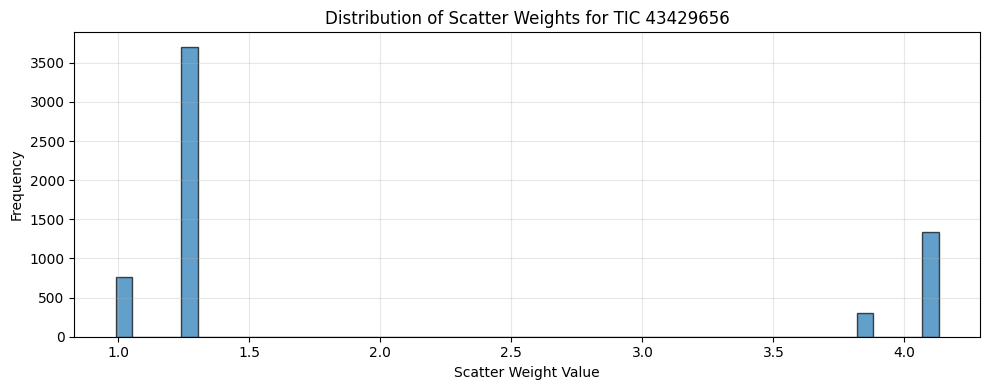

In [150]:
# Calculate scatter weights from the phase-folded light curve
scatter_weights = preprocess.split_and_calculate_weights(detrended_time, detrended_flux, gap_width=2)

print(f"Scatter weights calculated: {len(scatter_weights)} points")
print(f"Weight range: [{scatter_weights.min():.4f}, {scatter_weights.max():.4f}]")
print(f"Mean weight: {scatter_weights.mean():.4f}")
print(f"Std weight: {scatter_weights.std():.4f}")

# Plot weight distribution
plt.figure(figsize=(10, 4))
plt.hist(scatter_weights, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel("Scatter Weight Value")
plt.ylabel("Frequency")
plt.title(f"Distribution of Scatter Weights for TIC {tce['TIC ID']}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


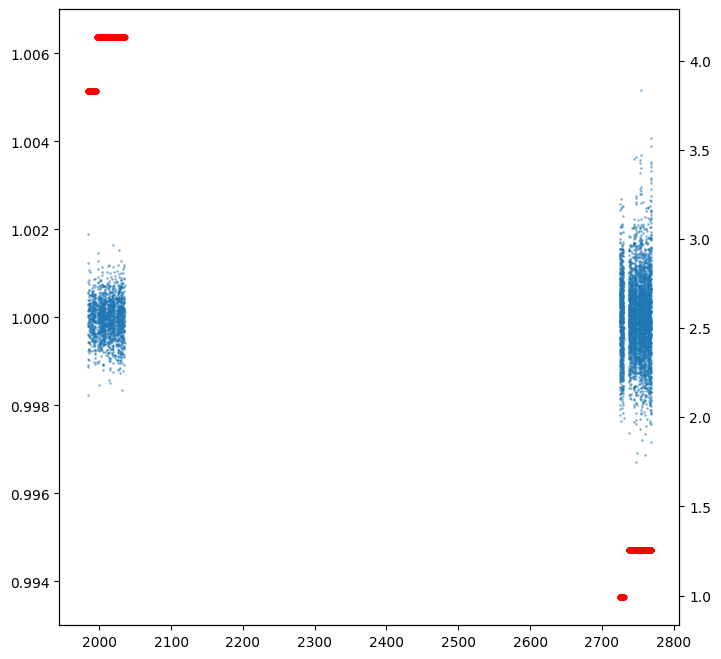

In [151]:
from pandas.compat import platform

fig, ax1 = plt.subplots(figsize=(8, 8))
ax2 = ax1.twinx()

ax1.plot(detrended_time,detrended_flux,  ".", ms=2, alpha=0.4)
ax1.set_ylim(0.993,1.007)
ax2.plot(detrended_time,scatter_weights, '.r')

In [152]:
# Phase fold and sort
folded_time, folded_flux, fold_num, tr_mask = preprocess.phase_fold_and_sort_light_curve(
    detrended_time, detrended_flux, transit_mask, tce.Per, epoch
)

# Align raw time for cadence selection
raw_time_aligned, raw_flux_aligned = preprocess.align_raw_time(
    detrended_time, detrended_flux, tce.Per, epoch
)

# Align the weights
weights_aligned = preprocess.align_scatter_weights(
    detrended_time, tce.Per, epoch, scatter_weights
)

print(f"\nAfter phase folding: {len(folded_time)} data points")
print(f"Number of unique folds: {len(np.unique(fold_num))}")

print(f'weights_aligned shape: {weights_aligned.shape}')


After phase folding: 6104 data points
Number of unique folds: 20
weights_aligned shape: (6104,)


## Generate Views: With vs Without Scatter Weights


In [153]:
# Generate global view WITHOUT scatter weights
view_no_weights, std_no_weights, mask_no_weights, _, _ = preprocess.global_view(
    tce['TIC ID'],
    folded_time,
    folded_flux,
    tce.Per,
    all_30min=True,
    raw_time=raw_time_aligned,
    raw_flux=raw_flux_aligned,
    scatter_weights=None  # No scatter weights
)

# Generate global view WITH scatter weights
view_with_weights, std_with_weights, mask_with_weights, _, _ = preprocess.global_view(
    tce['TIC ID'],
    folded_time,
    folded_flux,
    tce.Per,
    all_30min=True,
    raw_time=raw_time_aligned,
    raw_flux=raw_flux_aligned,
    scatter_weights=weights_aligned # With scatter weights
)

print("Global views generated successfully")
print(f"Difference (with - without): max={np.abs(view_with_weights - view_no_weights).max():.6f}, ")
print(f"  mean={np.abs(view_with_weights - view_no_weights).mean():.6f}")


Global views generated successfully
Difference (with - without): max=0.174049, 
  mean=0.047798


## Compare Global Views


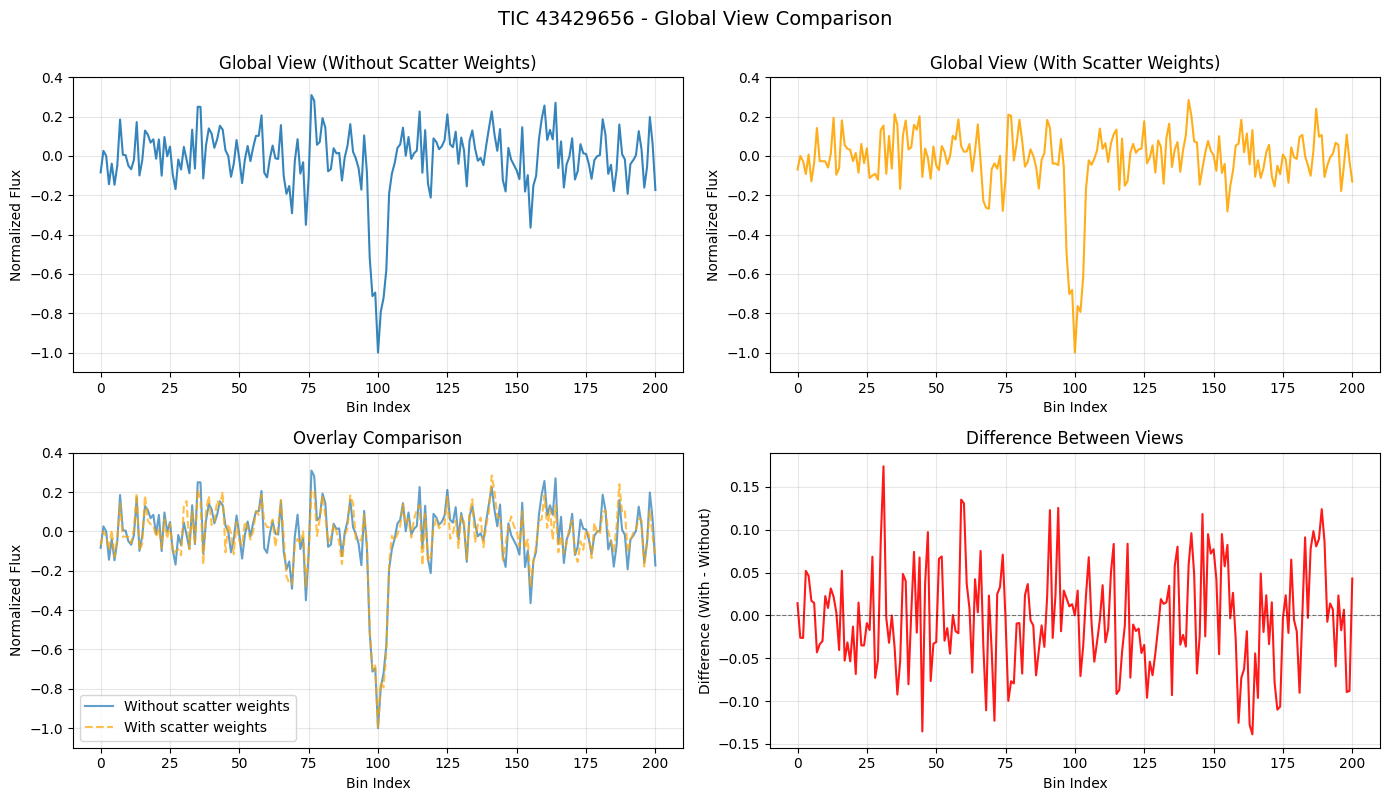

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

x = np.arange(len(view_no_weights))

# Plot 1: Without scatter weights
axes[0, 0].plot(x, view_no_weights, '-', linewidth=1.5, alpha=0.9, label='Without scatter weights')
axes[0, 0].set_xlabel('Bin Index')
axes[0, 0].set_ylabel('Normalized Flux')
axes[0, 0].set_title('Global View (Without Scatter Weights)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-1.1, 0.4)

# Plot 2: With scatter weights
axes[0, 1].plot(x, view_with_weights, '-', linewidth=1.5, alpha=0.9, label='With scatter weights', color='orange')
axes[0, 1].set_xlabel('Bin Index')
axes[0, 1].set_ylabel('Normalized Flux')
axes[0, 1].set_title('Global View (With Scatter Weights)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-1.1, 0.4)

# Plot 3: Overlay comparison
axes[1, 0].plot(x, view_no_weights, '-', linewidth=1.5, alpha=0.7, label='Without scatter weights')
axes[1, 0].plot(x, view_with_weights, '--', linewidth=1.5, alpha=0.7, label='With scatter weights', color='orange')
axes[1, 0].set_xlabel('Bin Index')
axes[1, 0].set_ylabel('Normalized Flux')
axes[1, 0].set_title('Overlay Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-1.1, 0.4)

# Plot 4: Difference
diff = view_with_weights - view_no_weights
axes[1, 1].plot(x, diff, '-', linewidth=1.5, alpha=0.9, color='red')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1, 1].set_xlabel('Bin Index')
axes[1, 1].set_ylabel('Difference (With - Without)')
axes[1, 1].set_title('Difference Between Views')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'TIC {tce["TIC ID"]} - Global View Comparison', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


## Compare Local Views


In [155]:
# Generate local view WITHOUT scatter weights
local_no_weights, std_local_no, mask_local_no, scale_no, depth_no = preprocess.local_view(
    tce['TIC ID'],
    folded_time,
    folded_flux,
    tce.Per,
    tce.Dur,
    all_30min=False,
    raw_time=raw_time_aligned,
    raw_flux=raw_flux_aligned,
    scatter_weights=None
)

# Generate local view WITH scatter weights
local_with_weights, std_local_with, mask_local_with, scale_with, depth_with = preprocess.local_view(
    tce['TIC ID'],
    folded_time,
    folded_flux,
    tce.Per,
    tce.Dur,
    all_30min=False,
    raw_time=raw_time_aligned,
    raw_flux=raw_flux_aligned,
    scatter_weights=weights_aligned
)

print("Local views generated successfully")
print(f"Difference (with - without): max={np.abs(local_with_weights - local_no_weights).max():.6f}, ")
print(f"  mean={np.abs(local_with_weights - local_no_weights).mean():.6f}")


Local views generated successfully
Difference (with - without): max=0.165296, 
  mean=0.049503


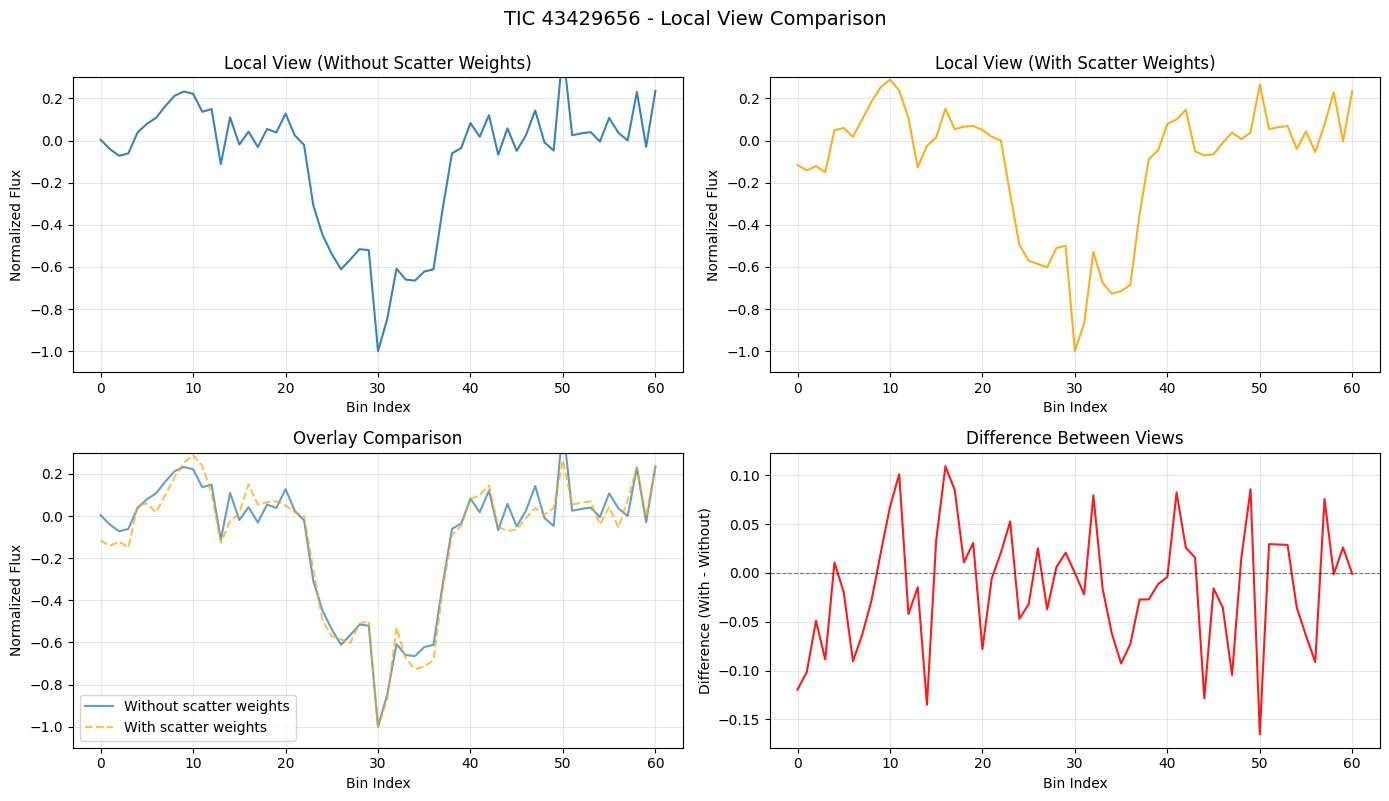

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

x_local = np.arange(len(local_no_weights))

# Plot 1: Without scatter weights
axes[0, 0].plot(x_local, local_no_weights, '-', linewidth=1.5, alpha=0.9)
axes[0, 0].set_xlabel('Bin Index')
axes[0, 0].set_ylabel('Normalized Flux')
axes[0, 0].set_title('Local View (Without Scatter Weights)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-1.1, 0.3)

# Plot 2: With scatter weights
axes[0, 1].plot(x_local, local_with_weights, '-', linewidth=1.5, alpha=0.9, color='orange')
axes[0, 1].set_xlabel('Bin Index')
axes[0, 1].set_ylabel('Normalized Flux')
axes[0, 1].set_title('Local View (With Scatter Weights)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-1.1, 0.3)

# Plot 3: Overlay comparison
axes[1, 0].plot(x_local, local_no_weights, '-', linewidth=1.5, alpha=0.7, label='Without scatter weights')
axes[1, 0].plot(x_local, local_with_weights, '--', linewidth=1.5, alpha=0.7, label='With scatter weights', color='orange')
axes[1, 0].set_xlabel('Bin Index')
axes[1, 0].set_ylabel('Normalized Flux')
axes[1, 0].set_title('Overlay Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-1.1, 0.3)

# Plot 4: Difference
diff_local = local_with_weights - local_no_weights
axes[1, 1].plot(x_local, diff_local, '-', linewidth=1.5, alpha=0.9, color='red')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1, 1].set_xlabel('Bin Index')
axes[1, 1].set_ylabel('Difference (With - Without)')
axes[1, 1].set_title('Difference Between Views')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'TIC {tce["TIC ID"]} - Local View Comparison', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


## Summary Statistics


In [157]:
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nTIC ID: {tce['TIC ID']}")
print(f"Astro ID: {astro_id_to_inspect}")
print(f"Period: {tce.Per:.4f} days")
print(f"Duration: {tce.Dur:.4f} days")
print(f"\nData points: {len(folded_time)}")
print(f"Number of folds: {len(np.unique(fold_num))}")
print(f"\nScatter weights:")
print(f"  Range: [{scatter_weights.min():.4f}, {scatter_weights.max():.4f}]")
print(f"  Mean: {scatter_weights.mean():.4f}")
print(f"  Std: {scatter_weights.std():.4f}")
print(f"\nGlobal View Differences:")
print(f"  Max absolute difference: {np.abs(view_with_weights - view_no_weights).max():.6f}")
print(f"  Mean absolute difference: {np.abs(view_with_weights - view_no_weights).mean():.6f}")
print(f"  RMS difference: {np.sqrt(np.mean((view_with_weights - view_no_weights)**2)):.6f}")
print(f"\nLocal View Differences:")
print(f"  Max absolute difference: {np.abs(local_with_weights - local_no_weights).max():.6f}")
print(f"  Mean absolute difference: {np.abs(local_with_weights - local_no_weights).mean():.6f}")
print(f"  RMS difference: {np.sqrt(np.mean((local_with_weights - local_no_weights)**2)):.6f}")


SUMMARY STATISTICS

TIC ID: 43429656
Astro ID: 4338
Period: 5.2132 days
Duration: 0.1827 days

Data points: 6104
Number of folds: 20

Scatter weights:
  Range: [0.9901, 4.1310]
  Mean: 1.9789
  Std: 1.2734

Global View Differences:
  Max absolute difference: 0.174049
  Mean absolute difference: 0.047798
  RMS difference: 0.059553

Local View Differences:
  Max absolute difference: 0.165296
  Mean absolute difference: 0.049503
  RMS difference: 0.062849
